In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score 

In [2]:
np.random.seed(42)  # Pour que les résultats soient reproductibles
n_samples = 500

# --- GR (Gamma Ray) ---

GR = np.random.normal(60, 25, n_samples)  
GR = np.clip(GR, 20, 150)  

# --- RHOB (Bulk Density) ---

RHOB = 2.65 - 0.4 * (GR/150) + np.random.normal(0, 0.08, n_samples)
RHOB = np.clip(RHOB, 2.0, 2.7)

# --- NPHI (Neutron Porosity) ---

NPHI = 0.05 + 0.002 * GR + np.random.normal(0, 0.03, n_samples)
NPHI = np.clip(NPHI, 0.02, 0.45)

# --- DT (Sonic / Temps de transit) ---

DT = 55 + 0.5 * GR + np.random.normal(0, 5, n_samples)
DT = np.clip(DT, 55, 140)

# --- CORE_POROSITY (notre CIBLE) ---

porosity = (2.65 - RHOB) / 1.65 * 0.35 + 0.3 * NPHI + 0.001 * (DT - 55) + np.random.normal(0, 0.015, n_samples)
porosity = np.clip(porosity, 0.02, 0.35)

# --- Depth ---
DEPTH = np.linspace(1500, 3500, n_samples)

# ---  DataFrame ---
df = pd.DataFrame({
    'DEPTH': DEPTH,
    'GR': GR,
    'RHOB': RHOB,
    'NPHI': NPHI,
    'DT': DT,
    'CORE_POROSITY': porosity
})

print("Dataset is create !")
print(f"Forme : {df.shape}")
print("\nFirst lignes :")
print(df.head())
print("\nStatistics :")
print(df.describe())

Dataset is create !
Forme : (500, 6)

First lignes :
         DEPTH         GR      RHOB      NPHI          DT  CORE_POROSITY
0  1500.000000  72.417854  2.530980  0.236816   95.100732       0.126265
1  1504.008016  56.543392  2.651971  0.190826   80.515768       0.080178
2  1508.016032  76.192213  2.334935  0.204173   89.005112       0.150203
3  1512.024048  98.075746  2.433502  0.226743  104.021001       0.158348
4  1516.032064  54.146166  2.453559  0.179239   81.222160       0.093259

Statistics :
             DEPTH          GR        RHOB        NPHI          DT  \
count   500.000000  500.000000  500.000000  500.000000  500.000000   
mean   2500.000000   60.553671    2.490266    0.174362   85.452179   
std     579.085502   23.666833    0.101927    0.054761   13.057982   
min    1500.000000   20.000000    2.158029    0.020978   55.000000   
25%    2000.000000   42.492315    2.415890    0.140083   76.518484   
50%    2500.000000   60.319929    2.493826    0.171229   84.498760   
75%  

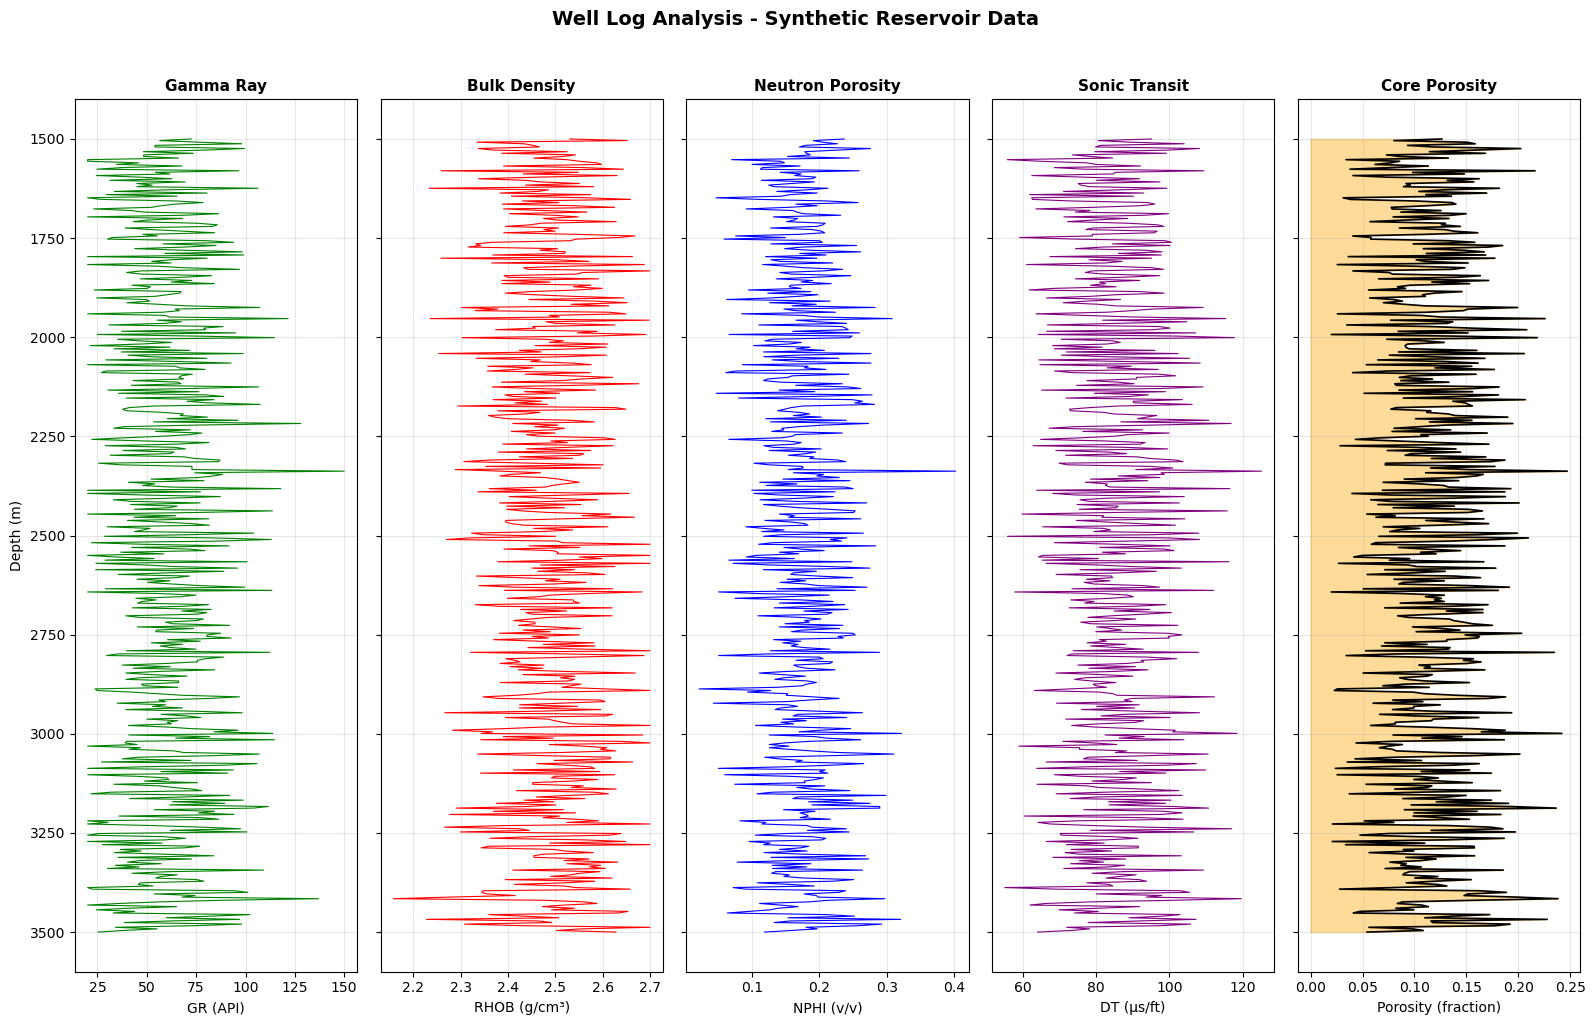

In [3]:
# ============================================
# GRAPH 1 : Well Log Plot (style industry)
# ============================================


fig, axes = plt.subplots(1, 5, figsize=(16, 10), sharey=True)

# --- Track 1 : GR (Gamma Ray) ---
axes[0].plot(df['GR'], df['DEPTH'], color='green', linewidth=0.8)
axes[0].set_xlabel('GR (API)', fontsize=10)
axes[0].set_ylabel('Depth (m)', fontsize=10)
axes[0].set_title('Gamma Ray', fontsize=11, fontweight='bold')
axes[0].invert_yaxis()  
axes[0].grid(True, alpha=0.3)

# --- Track 2 : RHOB (Density) ---
axes[1].plot(df['RHOB'], df['DEPTH'], color='red', linewidth=0.8)
axes[1].set_xlabel('RHOB (g/cm³)', fontsize=10)
axes[1].set_title('Bulk Density', fontsize=11, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3)

# --- Track 3 : NPHI (Neutron) ---
axes[2].plot(df['NPHI'], df['DEPTH'], color='blue', linewidth=0.8)
axes[2].set_xlabel('NPHI (v/v)', fontsize=10)
axes[2].set_title('Neutron Porosity', fontsize=11, fontweight='bold')
axes[2].invert_yaxis()
axes[2].grid(True, alpha=0.3)

# --- Track 4 : DT (Sonic) ---
axes[3].plot(df['DT'], df['DEPTH'], color='purple', linewidth=0.8)
axes[3].set_xlabel('DT (µs/ft)', fontsize=10)
axes[3].set_title('Sonic Transit', fontsize=11, fontweight='bold')
axes[3].invert_yaxis()
axes[3].grid(True, alpha=0.3)

# --- Track 5 : CORE_POROSITY (notre cible) ---
axes[4].plot(df['CORE_POROSITY'], df['DEPTH'], color='black', linewidth=1.2)
axes[4].fill_betweenx(df['DEPTH'], 0, df['CORE_POROSITY'], color='orange', alpha=0.4)
axes[4].set_xlabel('Porosity (fraction)', fontsize=10)
axes[4].set_title('Core Porosity', fontsize=11, fontweight='bold')
axes[4].invert_yaxis()
axes[4].grid(True, alpha=0.3)

plt.suptitle('Well Log Analysis - Synthetic Reservoir Data', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

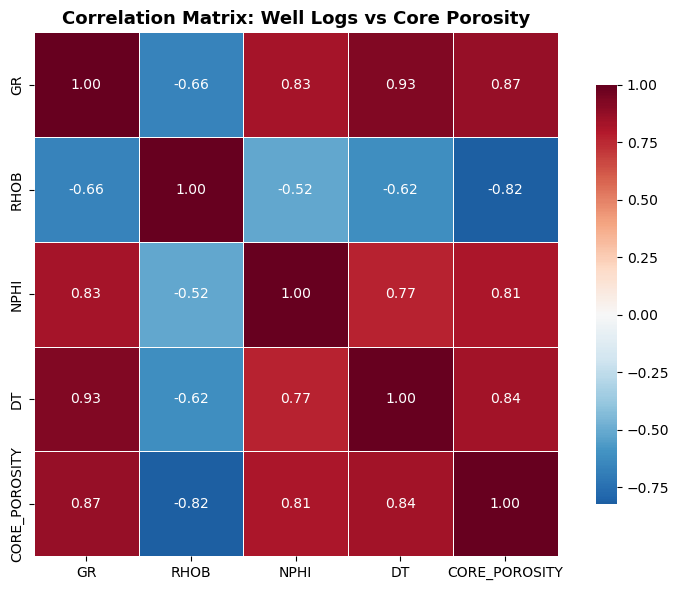


Interpretation for porosity prediction:
• RHOB vs CORE_POROSITY : -0.823 (strong negative: low density = high porosity)
• NPHI vs CORE_POROSITY : 0.810 (strong positive)
• DT vs CORE_POROSITY   : 0.837 (positive)
• GR vs CORE_POROSITY   : 0.868 (weak negative: shale = fewer pores)


In [4]:
# ============================================
# GRAPH 2: Correlation Matrix
# ============================================
# Correlation = strength of relationship between 2 variables
# +1 = perfect positive (when X increases, Y increases)
# -1 = perfect negative (when X increases, Y decreases)
# 0 = no relationship

# Remove DEPTH as it is just an index here
corr = df[['GR', 'RHOB', 'NPHI', 'DT', 'CORE_POROSITY']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, fmt='.2f',
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Well Logs vs Core Porosity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretation for porosity prediction:")
print(f"• RHOB vs CORE_POROSITY : {corr.loc['RHOB', 'CORE_POROSITY']:.3f} (strong negative: low density = high porosity)")
print(f"• NPHI vs CORE_POROSITY : {corr.loc['NPHI', 'CORE_POROSITY']:.3f} (strong positive)")
print(f"• DT vs CORE_POROSITY   : {corr.loc['DT', 'CORE_POROSITY']:.3f} (positive)")
print(f"• GR vs CORE_POROSITY   : {corr.loc['GR', 'CORE_POROSITY']:.3f} (weak negative: shale = fewer pores)")

In [5]:
# ============================================
# STEP 5: Train-Test Split
# ============================================
# Features (X) = the logs we use to predict
# Target (y) = the porosity we want to predict

X = df[['GR', 'RHOB', 'NPHI', 'DT']]  # Input variables
y = df['CORE_POROSITY']                # Target variable

# Split: 80% train, 20% test
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]} (GR, RHOB, NPHI, DT)")

Training set size: 400 samples
Test set size: 100 samples
Number of features: 4 (GR, RHOB, NPHI, DT)


In [6]:
# ============================================
# STEP 6: Train Random Forest Regressor
# ============================================
# Random Forest = ensemble of decision trees
# Each tree learns patterns from the logs to predict porosity
# Final prediction = average of all trees

# Initialize the model
model = RandomForestRegressor(
    n_estimators=100,    # Number of trees in the forest
    max_depth=10,        # Maximum depth of each tree
    random_state=42,     # For reproducibility
    n_jobs=-1            # Use all CPU cores for speed
)

# Train the model on training data
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Number of trees: {model.n_estimators}")
print(f"Features used: {list(X.columns)}")

Model trained successfully!
Number of trees: 100
Features used: ['GR', 'RHOB', 'NPHI', 'DT']


In [7]:
# ============================================
# STEP 7: Predictions and Model Evaluation
# ============================================

# Predict on test data (unseen during training)
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("MODEL PERFORMANCE ON TEST DATA")
print("=" * 50)
print(f"Mean Absolute Error (MAE) : {mae:.4f}")
print(f"Root Mean Squared Error   : {rmse:.4f}")
print(f"R² Score                  : {r2:.4f}")
print("=" * 50)
print("\nInterpretation:")
print(f"• On average, predictions are off by {mae:.4f} porosity units")
print(f"• The model explains {r2*100:.1f}% of porosity variance")

MODEL PERFORMANCE ON TEST DATA
Mean Absolute Error (MAE) : 0.0132
Root Mean Squared Error   : 0.0172
R² Score                  : 0.8722

Interpretation:
• On average, predictions are off by 0.0132 porosity units
• The model explains 87.2% of porosity variance


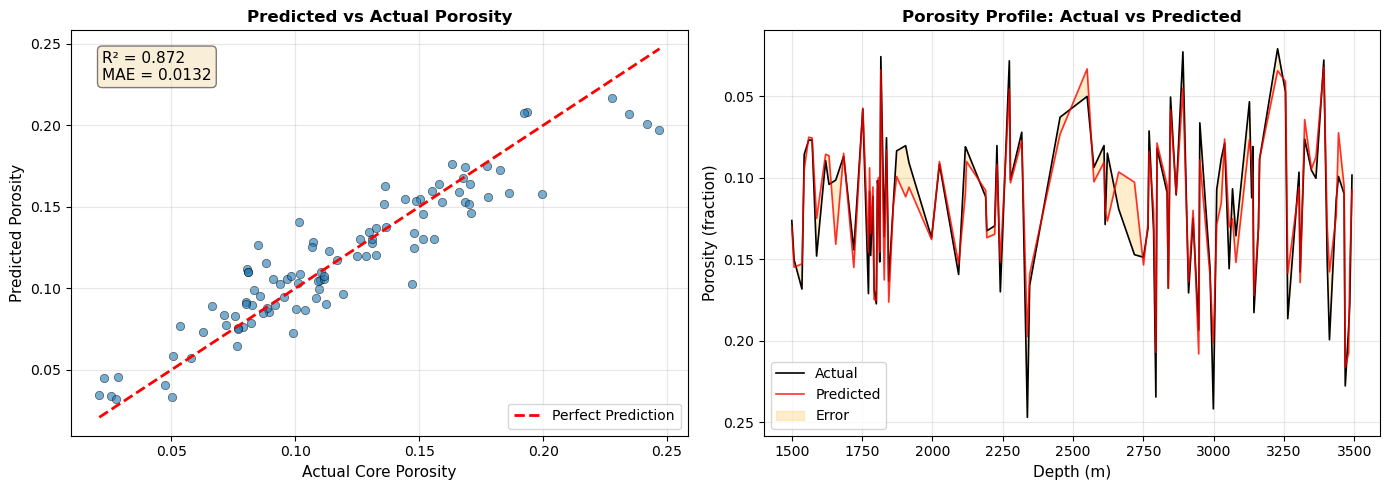

In [8]:
# ============================================
# STEP 8: Predicted vs Actual Porosity
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Scatter plot (Predicted vs Actual) ---
axes[0].scatter(y_test, y_pred, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Core Porosity', fontsize=11)
axes[0].set_ylabel('Predicted Porosity', fontsize=11)
axes[0].set_title('Predicted vs Actual Porosity', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Add R² annotation
axes[0].text(0.05, 0.95, f'R² = {r2:.3f}\nMAE = {mae:.4f}', 
             transform=axes[0].transAxes, fontsize=11,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# --- Plot 2: Depth-based comparison ---
# Sort test data by depth for clean visualization
test_df = X_test.copy()
test_df['DEPTH'] = df.loc[X_test.index, 'DEPTH']
test_df['Actual'] = y_test
test_df['Predicted'] = y_pred
test_df = test_df.sort_values('DEPTH')

axes[1].plot(test_df['DEPTH'], test_df['Actual'], label='Actual', color='black', linewidth=1.2)
axes[1].plot(test_df['DEPTH'], test_df['Predicted'], label='Predicted', color='red', linewidth=1.2, alpha=0.8)
axes[1].fill_between(test_df['DEPTH'], test_df['Actual'], test_df['Predicted'], 
                     alpha=0.2, color='orange', label='Error')
axes[1].set_xlabel('Depth (m)', fontsize=11)
axes[1].set_ylabel('Porosity (fraction)', fontsize=11)
axes[1].set_title('Porosity Profile: Actual vs Predicted', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].invert_yaxis()  # Depth increases downward

plt.tight_layout()
plt.show()

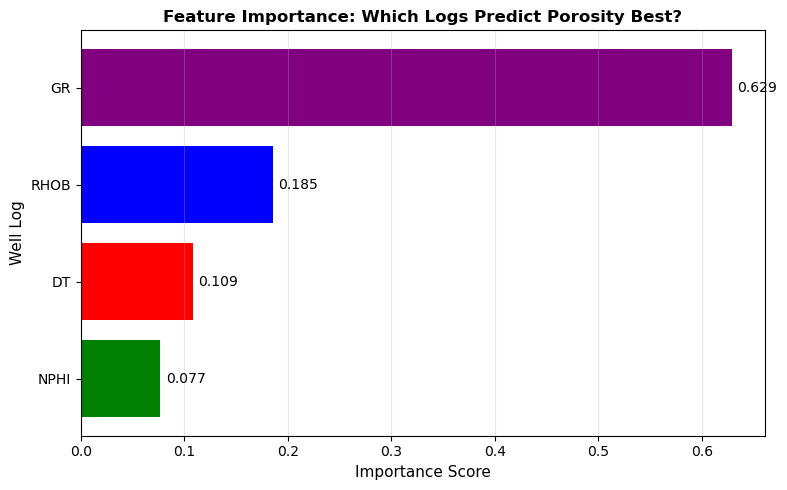


Ranking of logs by predictive power:
    NPHI : 0.077
      DT : 0.109
    RHOB : 0.185
      GR : 0.629


In [9]:
# ============================================
# STEP 9: Feature Importance
# ============================================
# Which logs contribute most to porosity prediction?

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance['Feature'], importance['Importance'], color=['green', 'red', 'blue', 'purple'])
plt.xlabel('Importance Score', fontsize=11)
plt.ylabel('Well Log', fontsize=11)
plt.title('Feature Importance: Which Logs Predict Porosity Best?', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

# Add values on bars
for i, v in enumerate(importance['Importance']):
    plt.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nRanking of logs by predictive power:")
for idx, row in importance.iterrows():
    print(f"  {row['Feature']:>6s} : {row['Importance']:.3f}")